## Incorporating Automatic Differentiation in `Tidy3D`

With that basic introduction to automatic differentiation using `autograd`, we can now show how `Tidy3D` lets us do the same thing but where our functions can now involve setting up, running, and postprocessing a `tidy3d.Simulation`.

In [1]:
import os
import numpy as np
import tidy3d as td
import tidy3d.web as web
from tidy3d.web import run
import matplotlib.pyplot as plt
import autograd.numpy as anp
import autograd as ag
from tidy3d.web.core.environment import Env, dev, prod
from tidy3d import GaussianPulse
from autograd.builtins import tuple as ag_tuple


td.config.logging_level = "INFO"

In [2]:
# function to get box size (um) as a function of the design parameter (-inf, inf)
    # wavelength and frequency
wavelength = 1.5
freq0 = td.C_0 / wavelength

# permittivity of box
eps_box = 2.

# size of sim in x,y,z
L = 10 * wavelength

# spc between sources, monitors, and PML / box
buffer = 1.0 * wavelength

size_min = 0
size_max = L - 4 * buffer

trans_min, trans_max = -L / 4, L / 4

    # Forward source
source = td.PointDipole(
    center=(-L / 2 + buffer, 0, 0),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10.0),
    polarization="Ez",
)

# Monitor
monitor = td.FieldMonitor(
center=(+L / 2 - buffer, 0.5*buffer, 0.5*buffer,),
size=(0.0, 0.0, 0.0),
freqs=[freq0],
name="point",
)


def get_size(param: float):
    """Size of box as function of parameter, smoothly maps (-inf, inf) to (size_min, size_max)."""
    param_01 = 0.5 * (anp.tanh(param) + 1)
    return (size_max * param_01) + (size_min * (1 - param_01))

def get_translation(param_translate: float):
    """Maps a parameter to translation in x-direction."""
    param_01 = 0.5 * (anp.tanh(param_translate) + 1)
    return trans_min + (trans_max - trans_min) * param_01

# Transformed Geometry

In [3]:
def make_simulation(center: tuple, size: tuple, scale: tuple, translate: tuple, eps: float, theta: float) -> td.Simulation:
    """Makes a simulation with a variable scatter width, height, and relative permittivity."""

    if center is None or size is None:
      return td.Simulation(
        size=(L, L, L),
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=60),
        structures=[],
        sources=[source],
        monitors=[monitor],
        run_time=120 / freq0,
      )
    # Geometry and transformation
    center1 = ag_tuple([center[0], center[1], center[2]])
    size1 = ag_tuple([size[0], size[1], size[2]])
    box = td.Box(center=center1, size=size1)
    transformed_geometry = box.rotated(theta, 0).scaled(x=scale[0], y=scale[1], z=scale[2]).translated(x=translate[0], y = translate[1], z = translate[2])
    dielectric_box = td.Structure(
        geometry=transformed_geometry,
        medium=td.Medium(permittivity=eps),
    )

    back_box = td.Box(center=(0.0, 0.0, 0.0), size=(4., 1.6, 1.6))
    background_box = td.Structure(
        geometry=back_box,
        medium=td.Medium(permittivity=1.5),
    )

    # Simulation setup

    return td.Simulation(
      size=(L, L, L),
      grid_spec=td.GridSpec.auto(min_steps_per_wvl=60),
      structures=[dielectric_box],
      sources=[source],
      monitors=[monitor],
      run_time=120 / freq0
    )


# Scaled Box


Let's try setting up the simulation and plotting it for starters.

17:28:34 EDT INFO: Auto meshing using wavelength 1.5000 defined from sources.

             INFO: Auto meshing using wavelength 1.5000 defined from sources.

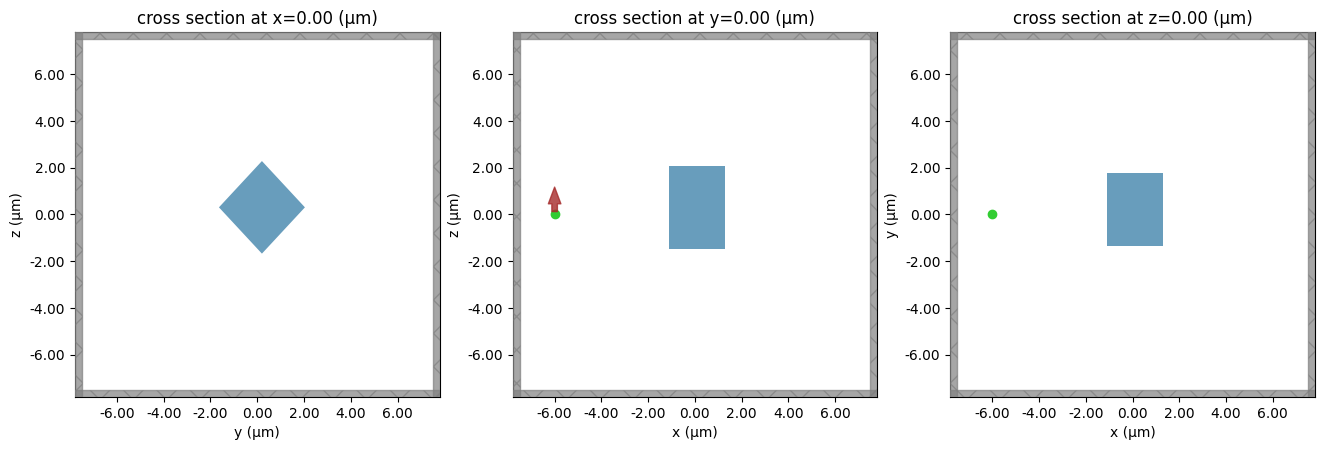

In [ ]:
# starting set of input parameters
center0 = (0., 0.0, 0.0)
# size0 = (get_size10.5), get_size(1.0), get_size(1.0)) 
size0 = (2., 2., 2.)
scale0 = anp.array([1.2, 1.3, 1.4])
translate0  = anp.array([2., 0.2, 0.3])
theta0 = np.pi/4.
eps0 = eps_box

sim = make_simulation(center=center0, size=size0, scale = scale0, translate = translate0,  eps=eps0, theta = theta0)
_, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, dim in zip(axes, "xyz"):
    sim.plot(**{dim: 0}, ax=ax)
    # sim.plot_grid(**{dim: 0}, ax=ax)
    # ax.set_xlim(-2.1, 2.1)
    # ax.set_ylim(-2.1, 2.1)
plt.show()

In [5]:
# function to compute and measure intensity as function of the design paramater


def measure_intensity(sim_data: td.SimulationData) -> float:
    """get intensity from SimulationData."""
    return anp.sum(sim_data.get_intensity(monitor.name).values)


def intensity(center, size, scale, translate, eps, theta) -> float:
    """Intensity measured at monitor as function of parameter."""

    # make the sim using the parameter value
    sim_with_square = make_simulation(center=center, size=size, scale=scale,translate=translate, eps=eps, theta=theta)

    # run sim through tidy3d web API
    data = run(sim_with_square, task_name="inverse_design", verbose=False, local_gradient=True)

    # evaluate the intensity at the measurement position
    return measure_intensity(data)

In [6]:
# get the intensity with no box, for normalization (care about enhancement, not abs value)
intensity_norm = intensity(center = None, size= None, scale= None, translate= None, eps= None, theta=None)
print(f"With no box, intensity = {intensity_norm:.4f}.")
print("This value will be used for normalization of the objective function.")

17:28:35 EDT INFO: Auto meshing using wavelength 1.5000 defined from sources.

             INFO: Auto meshing using wavelength 1.5000 defined from sources.

17:28:38 EDT INFO: Auto meshing using wavelength 1.5000 defined from sources.

             INFO: Auto meshing using wavelength 1.5000 defined from sources.

With no box, intensity = 108.1617.
This value will be used for normalization of the objective function.


In [7]:
def objective_fn(center, size, scale, translate, eps, theta):
    """Objective function: maximize intensity at monitor."""
    return intensity(center, size, scale, translate, eps, theta)

In [8]:
# #plot intensity distribution

# # add a field monitor for plotting
# fld_mnt = td.FieldMonitor(
#     center=(+L / 2 - buffer, 0, 0),
#     size=(td.inf, td.inf, 0),
#     freqs=[freq0],
#     name="fields",
# )
# sim_final = sim.updated_copy(monitors=[monitor, fld_mnt])

# # run simulation
# data_final = run(sim_final, task_name="quickstart_final", verbose=False)


In [9]:
# ax = data_final.plot_field(
#     field_monitor_name="fields", field_name="E", val="abs^2",  robust=True
# )

# ax.plot(source.center[0], 0, marker="o", mfc="limegreen", mec="black", ms=10)
# ax.plot(monitor.center[0], 0, marker="o", mfc="orange", mec="black", ms=10)
# plt.show()

In [10]:
val_and_grad_fn = ag.value_and_grad(objective_fn, argnum=(0, 1, 2, 3, 4, 5))

We will run this function and assign variables to the power values and the gradients returned.

Note that running this will set off **two** separate tasks, one after another, called, `"adjoint_power_fwd"` and `"adjoint_power_adj"`.

The first is evaluating our simulation in "forward mode", computing the power and stashing information needed for gradient computation.

The second step runs the "adjoint" simulation, in which the output monitor is converted to a source and the simulation is re-run.

The results of both of these simulations runs are combined behind the scene to tell `autograd` how to compute the gradient for us.

In [ ]:
power_value, (dp_dcenter, dp_dsize, dp_dscale, dp_dtranslate, dp_deps, dp_dtheta) = val_and_grad_fn(center0, size0, scale0, translate0, eps0, theta0)

17:28:39 EDT INFO: Auto meshing using wavelength 1.5000 defined from sources.

             INFO: Auto meshing using wavelength 1.5000 defined from sources.

             INFO: Auto meshing using wavelength 1.5000 defined from sources.

             INFO: Auto meshing using wavelength 1.5000 defined from sources.

             INFO: running primitive '_run_primitive()'

             INFO: Auto meshing using wavelength 1.5000 defined from sources.

             INFO: Auto meshing using wavelength 1.5000 defined from sources.

             INFO: running tidy3d_autograd simulation with '_run_tidy3d()'

> Note: the gradient evaluation functions returned by `autograd.grad()` do not accept keyword arguments (ie. `center=(0.,0.,0.)`) and instead accept positional arguments (without the argument name). You may run across this when trying to evaluate gradients so it's a good idea to keep in mind.

We can take a look at our computed power and gradient information. 

In [ ]:
print(f"power = {power_value:.5f}")
print(f"d_power/d_center = {dp_dcenter}")
print(f"d_power/d_size = {dp_dsize}")
print(f"d_power/d_scale = {dp_dscale}")
print(f"d_power/d_translate = {dp_dtranslate}")
print(f"d_power/d_eps = {dp_deps}")
print(f"d_power/d_theta = {dp_dtheta}")

In [ ]:
def finite_diff_theta(power_fn, center, size, scale, translate, eps, theta, delta=1e-3):
  """
  Finite-difference check for d(power)/d(theta).
  """

  # +delta on theta
  theta_plus = theta + delta
  p_plus = power_fn(center, size, scale, translate, eps, theta_plus)

  # -delta on theta
  theta_minus = theta - delta
  p_minus = power_fn(center, size, scale, translate, eps, theta_minus)

  # Central-difference derivative
  grad_theta = (p_plus - p_minus) / (2.0 * delta)

  print(f"Power at theta + {delta}:        {p_plus:.8f}")
  print(f"Power at theta - {delta}:        {p_minus:.8f}")
  print(f"Finite-difference derivative wrt theta = {grad_theta:.8f}")

  return grad_theta


grad_theta = finite_diff_theta(
  objective_fn,
  center0,
  size0,
  scale0,
  translate0,
  eps0,
  theta = theta0,
  delta=0.014
)


In [ ]:
deltas = np.array([0.001, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03])

grads = [
    finite_diff_theta(
        objective_fn,
        center0,
        size0,
        scale0,
        translate0,
        eps0,
        theta0,
        delta
    )
    for delta in deltas
]

# 3) Plot on a linear Δθ axis
plt.figure(figsize=(6, 4))
plt.plot(deltas, grads, marker='o')
plt.xlabel('Finite-difference step Δθ')
plt.ylabel('Approx. ∂Power/∂θ')
plt.title('Gradient vs. Δθ (Linear Scale)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Fixed delta
delta = 0.016
theta_sweep = np.array([2*delta, 2*np.pi-2*delta])   # for example, 25 points



finite_diff_grads = []
autograd_grads = []

for theta in theta_sweep:
    # Autograd gradient
    _, (dp_dcenter, dp_dsize, dp_dscale, dp_dtranslate, dp_deps, dp_dtheta) = val_and_grad_fn(
        center0, size0, scale0, translate0, eps0, theta
    )
    autograd_grads.append(dp_dtheta)

    # Finite difference gradient
    fd_grad = finite_diff_theta(
        objective_fn,
        center0,
        size0,
        scale0,
        translate0,
        eps0,
        theta,
        delta=delta
    )
    finite_diff_grads.append(fd_grad)


In [ ]:
np.linspace(0.0, 360, 13)

In [ ]:
finite_diff_grads

In [ ]:
autograd_grads

In [ ]:
delta = 0.016

# ----- data -----
fd = np.array([
    48.070904,  -188.08269,  -166.31602,
    -54.372784, 140.72466,   110.398285,
    -166.31697, 110.398285,  147.73463
], dtype=np.float32)

ag = np.array([
     51.45214957, -201.18349503, -162.14142486,
    -57.20578285, 137.74392119,  104.26625094,
    -162.14138954, 104.26625094, 149.26463276
])
                                      # same δ used in FD sweep
theta_sweep = np.array([
    2*delta, np.pi/8, np.pi/6, np.pi/4,
    np.pi/3, np.pi/2, 2*np.pi/3, np.pi,
    2*np.pi - 2*delta
])

# ----- plot -----
plt.figure(figsize=(7, 4))
plt.plot(theta_sweep, fd, marker='o', label='Finite Difference (FD)')
plt.plot(theta_sweep, ag, marker='*', label='Adjoint (AG)', linestyle='--')
plt.xlabel(r'$\theta$ (rad) rotation angle')
plt.ylabel(r'Gradients')
plt.title('FD vs. Adjoint Gradient across $\\theta$ sweep')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

# Now plot
plt.figure(figsize=(6,4))
plt.plot(theta_sweep, finite_diff_grads, marker='o', label='Finite Difference')
plt.plot(theta_sweep, autograd_grads, marker='x', label='Autograd', linestyle='--')
plt.xlabel('Theta (radians)')
plt.ylabel('∂power/∂θ')
plt.title(f'Gradient vs. Theta')
# plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
def finite_diff_size_x(power_fn, center, size, scale, translate, eps, delta=1e-3):
    """
    Finite-difference check for d(power)/d(size_x).
    """

    size_arr = np.array(size)

    # +delta on x-component
    size_plus = size_arr.copy()
    size_plus[1] += delta
    p_plus = power_fn(center, tuple(size_plus), scale, translate, eps)

    # -delta on x-component
    size_minus = size_arr.copy()
    size_minus[1] -= delta
    p_minus = power_fn(center, tuple(size_minus), scale, translate, eps)

    # Central-difference derivative
    grad_size_x = (p_plus - p_minus) / (2.0 * delta)

    print(f"Power at size_x + {delta}:        {p_plus:.5f}")
    print(f"Power at size_x - {delta}:        {p_minus:.5f}")
    print(f"Finite-difference derivative wrt size_x = {grad_size_x:.5f}")

    return grad_size_x



grad_x = finite_diff_size_x(
    objective_fn,
    center0,
    size0,
    scale0,
    translate0,
    eps0,
    delta=0.03
)



From this, we can infer several things that fit our intuition, for example that:
* the transmitted power should **decrease** if we increase the permittivity of our scatterer.
* the transmitted power does not depend strongly on the position of the scatterer along the propagation direction.

## Conclusion & Next Steps

This gives the most basic introduction to the principles behind the adjoint plugin.

In subsequent notebooks, we will show how to:
 * Check the gradients returned by this method against brute force computed gradients for accuracy.
 * Perform gradient-based optimization using the adjoint plugin.

In [ ]:
def finite_diff_center_x(power_fn, center, size, scale, translate, eps, delta=1e-3):
  """
  Finite-difference check for d(power)/d(center_x).
  """

  center_arr = np.array(center)

  # +delta on x-component
  center_plus = center_arr.copy()
  center_plus[2] += delta
  p_plus = power_fn(tuple(center_plus), size, scale, translate, eps)

  # -delta on x-component
  center_minus = center_arr.copy()
  center_minus[2] -= delta
  p_minus = power_fn(tuple(center_minus), size, scale, translate, eps)

  # Central-difference derivative
  grad_center_x = (p_plus - p_minus) / (2.0 * delta)

  print(f"Power at center_x + {delta}:        {p_plus:.5f}")
  print(f"Power at center_x - {delta}:        {p_minus:.5f}")
  print(f"Finite-difference derivative wrt center_x = {grad_center_x:.5f}")

  return grad_center_x


grad_center_x = finite_diff_center_x(
  objective_fn,
  center0,
  size0,
  scale0,
  translate0,
  eps0,
  delta=0.0375
)
